In [30]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler


In [2]:
df = pd.read_csv("/content/synthetic_clinical_dataset.csv")
df.head()

,patient_id,age,sex,bmi,systolic_bp,diastolic_bp,glucose,cholesterol,creatinine,diabetes,hypertension,readmission_30d,mortality
0,1001,63,Male,24.1,131,81,136.2,210.3,1.04,0,0,0,0
1,1002,52,Male,20.8,118,91,136.5,207.9,1.49,0,1,0,0
2,1003,66,Male,30.0,144,73,100.0,179.5,1.15,0,0,0,0
3,1004,82,Male,16.8,112,76,117.3,228.3,0.59,0,0,0,0
4,1005,50,Female,25.4,102,65,128.0,150.7,1.38,0,0,0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   patient_id       10000 non-null  int64  
 1   age              10000 non-null  int64  
 2   sex              10000 non-null  object 
 3   bmi              10000 non-null  float64
 4   systolic_bp      10000 non-null  int64  
 5   diastolic_bp     10000 non-null  int64  
 6   glucose          10000 non-null  float64
 7   cholesterol      10000 non-null  float64
 8   creatinine       10000 non-null  float64
 9   diabetes         10000 non-null  int64  
 10  hypertension     10000 non-null  int64  
 11  readmission_30d  10000 non-null  int64  
 12  mortality        10000 non-null  int64  
dtypes: float64(4), int64(8), object(1)
memory usage: 1015.8+ KB


- Exploring the dataset: checking column types, missing values, and understanding which features are numeric or categorical.
- We will drop non-essential columns for ML such as 'patient_id' (just an ID) and keep 'diabetes', 'hypertension',
- 'readmission_30d' and 'mortality' for later validation after clustering.

In [4]:
# Drop the patient_id column as it is just an identifier
df_ml = df.drop(columns=['patient_id','mortality','readmission_30d'])

df_ml.head()

,age,sex,bmi,systolic_bp,diastolic_bp,glucose,cholesterol,creatinine,diabetes,hypertension
0,63,Male,24.1,131,81,136.2,210.3,1.04,0,0
1,52,Male,20.8,118,91,136.5,207.9,1.49,0,1
2,66,Male,30.0,144,73,100.0,179.5,1.15,0,0
3,82,Male,16.8,112,76,117.3,228.3,0.59,0,0
4,50,Female,25.4,102,65,128.0,150.7,1.38,0,0


In [5]:
missing_counts = df_ml.isnull().sum()
print(missing_counts)

age             0
sex             0
bmi             0
systolic_bp     0
diastolic_bp    0
glucose         0
cholesterol     0
creatinine      0
diabetes        0
hypertension    0
dtype: int64


In [6]:
print(df_ml['sex'].unique())

['Male' 'Female' 'Other']


In [7]:
num_other = (df_ml['sex'] == 'Other').sum()
print(f"Number of 'Other' in sex column: {num_other}")

Number of 'Other' in sex column: 116


In [8]:
# Remove rows where sex is 'Other' because the number is small (~116)
# and keeping 'Male' and 'Female' is important for clustering
df_ml = df_ml[df_ml['sex'] != 'Other']

In [9]:
# Convert categorical column 'sex' to numeric: Male = 0, Female = 1
df_ml['sex'] = df_ml['sex'].map({'Male': 0, 'Female': 1})

df_ml.head()

,age,sex,bmi,systolic_bp,diastolic_bp,glucose,cholesterol,creatinine,diabetes,hypertension
0,63,0,24.1,131,81,136.2,210.3,1.04,0,0
1,52,0,20.8,118,91,136.5,207.9,1.49,0,1
2,66,0,30.0,144,73,100.0,179.5,1.15,0,0
3,82,0,16.8,112,76,117.3,228.3,0.59,0,0
4,50,1,25.4,102,65,128.0,150.7,1.38,0,0


In [10]:
df_ml.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9884 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           9884 non-null   int64  
 1   sex           9884 non-null   int64  
 2   bmi           9884 non-null   float64
 3   systolic_bp   9884 non-null   int64  
 4   diastolic_bp  9884 non-null   int64  
 5   glucose       9884 non-null   float64
 6   cholesterol   9884 non-null   float64
 7   creatinine    9884 non-null   float64
 8   diabetes      9884 non-null   int64  
 9   hypertension  9884 non-null   int64  
dtypes: float64(4), int64(6)
memory usage: 849.4 KB


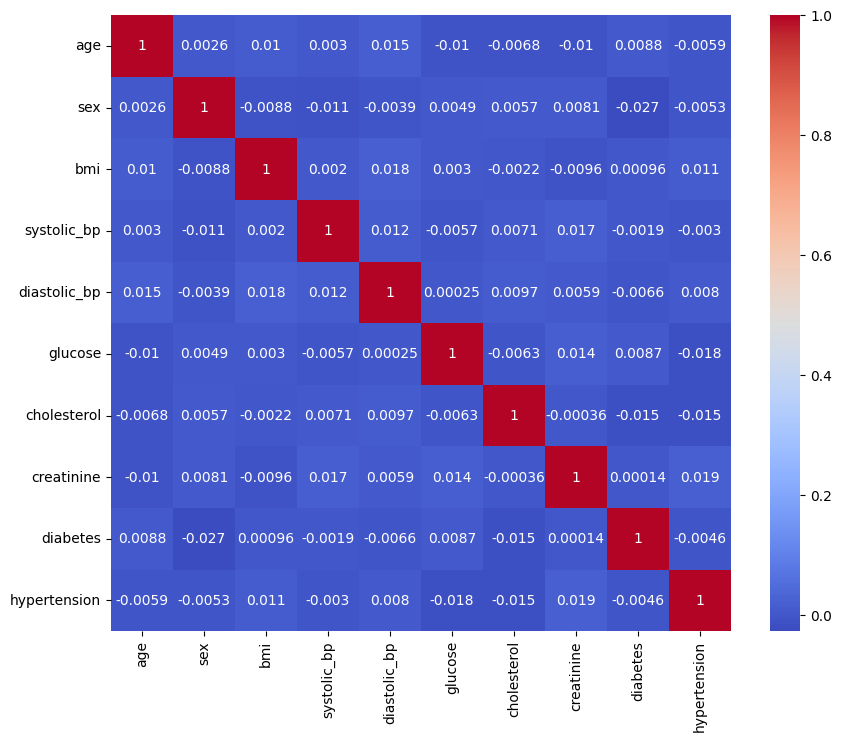

In [11]:
# correlation matrix
corr_matrix = df_ml[['age','sex','bmi','systolic_bp','diastolic_bp','glucose','cholesterol','creatinine','diabetes','hypertension']].corr()

# heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

- All features are numerical and ready for unsupervised learning.
- Checked correlation between features and found no high correlation,
- so we will keep all of them for clustering.

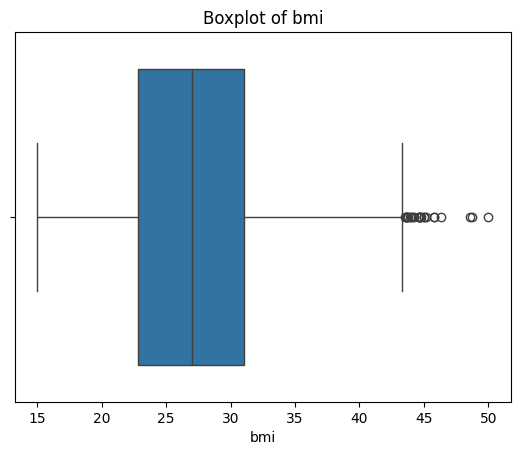

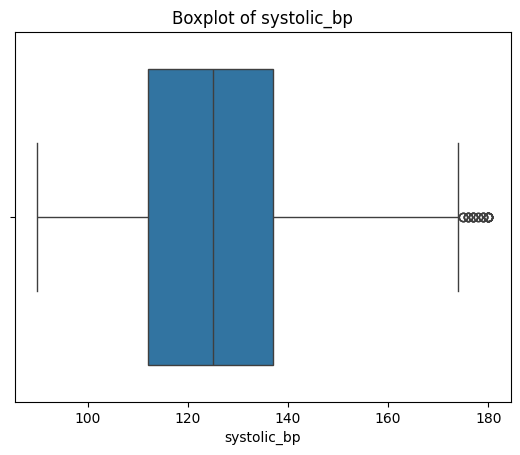

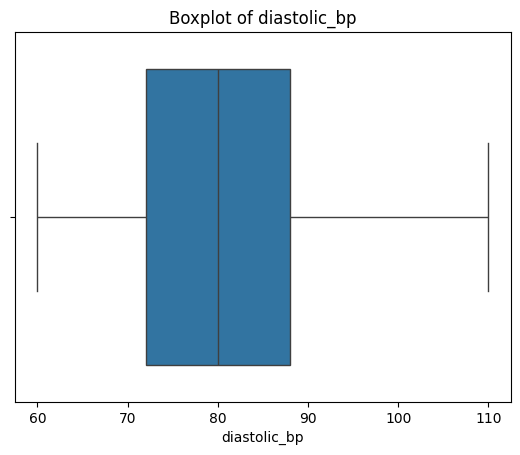

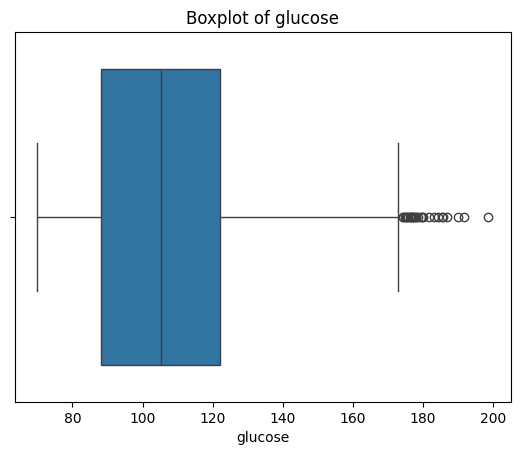

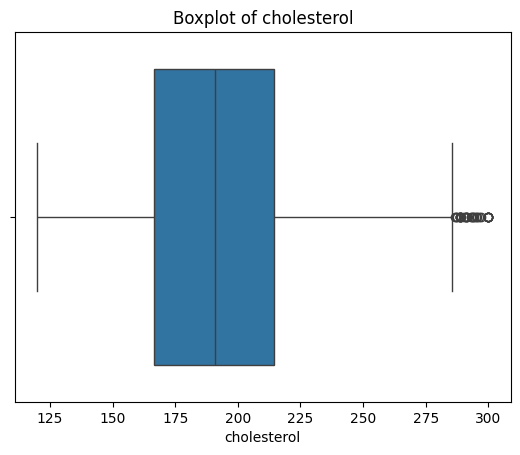

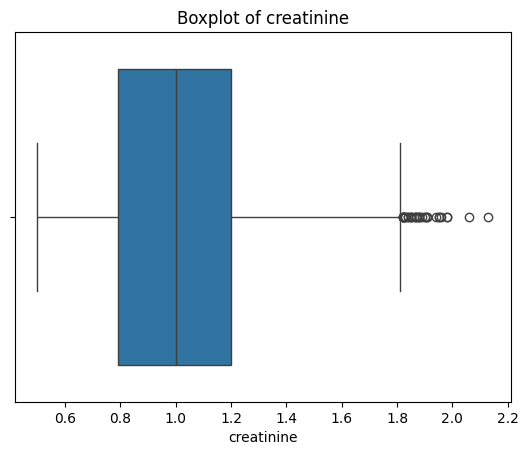

In [12]:
cols_to_check = ['bmi','systolic_bp','diastolic_bp','glucose','cholesterol','creatinine']

for col in cols_to_check:
    sns.boxplot(x=df_ml[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [13]:
cols_to_check = ['bmi','systolic_bp','diastolic_bp','glucose','cholesterol','creatinine']

for col in cols_to_check:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_ml[col] = df_ml[col].clip(lower, upper)

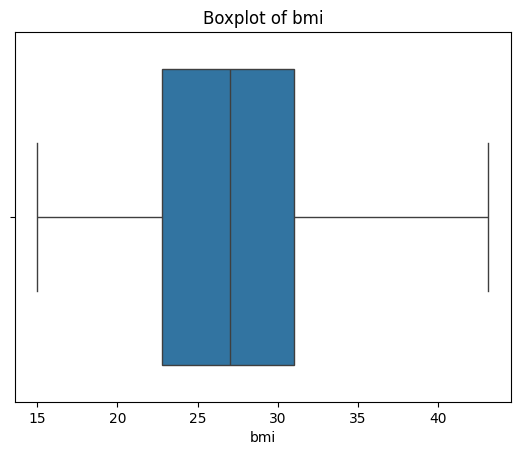

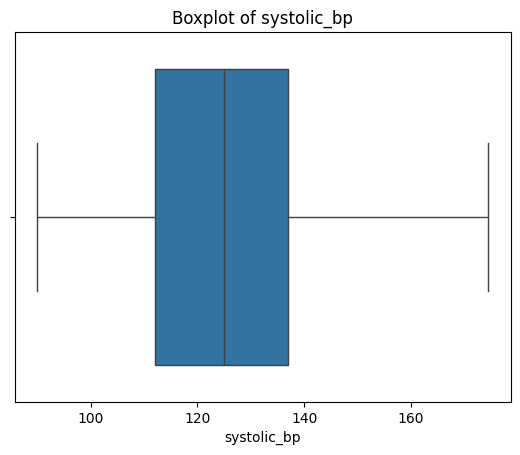

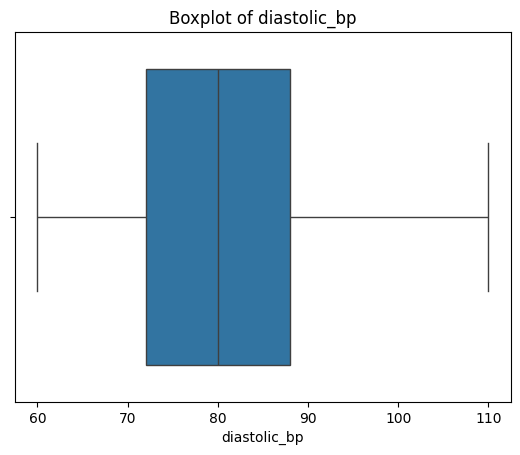

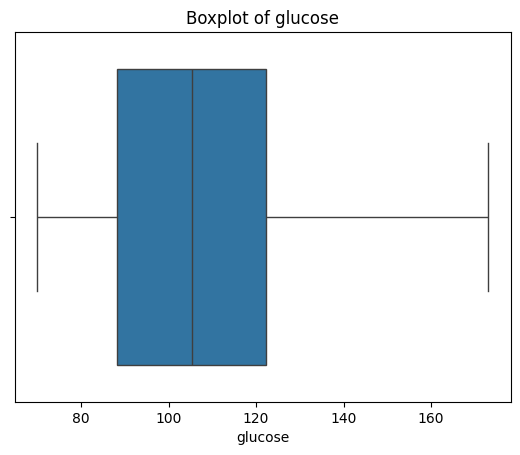

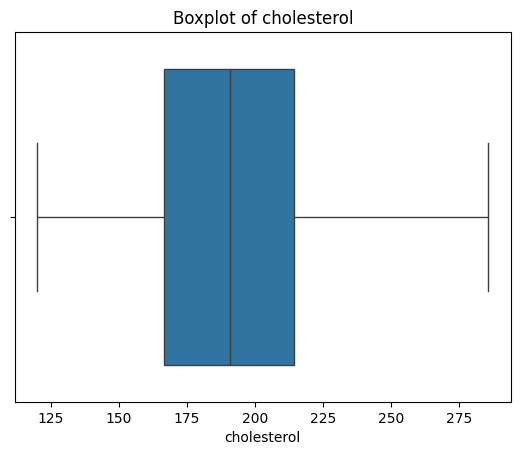

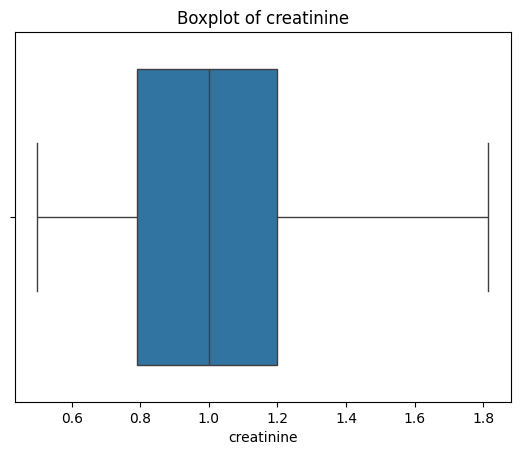

In [14]:
for col in cols_to_check:
    sns.boxplot(x=df_ml[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [15]:
# scalling
cols_to_scale = ['age','sex','bmi','systolic_bp','diastolic_bp','glucose','cholesterol','creatinine','diabetes','hypertension']

scaler = StandardScaler()
df_scaled = df_ml.copy()
df_scaled[cols_to_scale] = scaler.fit_transform(df_ml[cols_to_scale])

df_scaled.head()

,age,sex,bmi,systolic_bp,diastolic_bp,glucose,cholesterol,creatinine,diabetes,hypertension
0,0.492122,-1.034802,-0.500261,0.351075,0.058076,1.293757,0.566612,0.127025,-0.367666,-0.662201
1,-0.130882,-1.034802,-1.068372,-0.385890,0.936724,1.306622,0.496668,1.696640,-0.367666,1.510116
2,0.662032,-1.034802,0.515451,1.088041,-0.644843,-0.258627,-0.330996,0.510709,-0.367666,-0.662201
3,1.568219,-1.034802,-1.756990,-0.726028,-0.381248,0.483258,1.091188,-1.442589,-0.367666,-0.662201
4,-0.244156,0.966369,-0.276460,-1.292924,-1.347762,0.942112,-1.170318,1.312956,-0.367666,-0.662201


- Scaling the features so that all numerical columns have the same scale.
- This ensures that features with larger values (like glucose or creatinine)
- do not dominate the clustering algorithm.
- StandardScaler is used to standardize features to have mean=0 and std=1.

In [16]:
missing_counts = df_scaled[cols_to_scale].isnull().sum()
print(missing_counts)

age             0
sex             0
bmi             0
systolic_bp     0
diastolic_bp    0
glucose         0
cholesterol     0
creatinine      0
diabetes        0
hypertension    0
dtype: int64


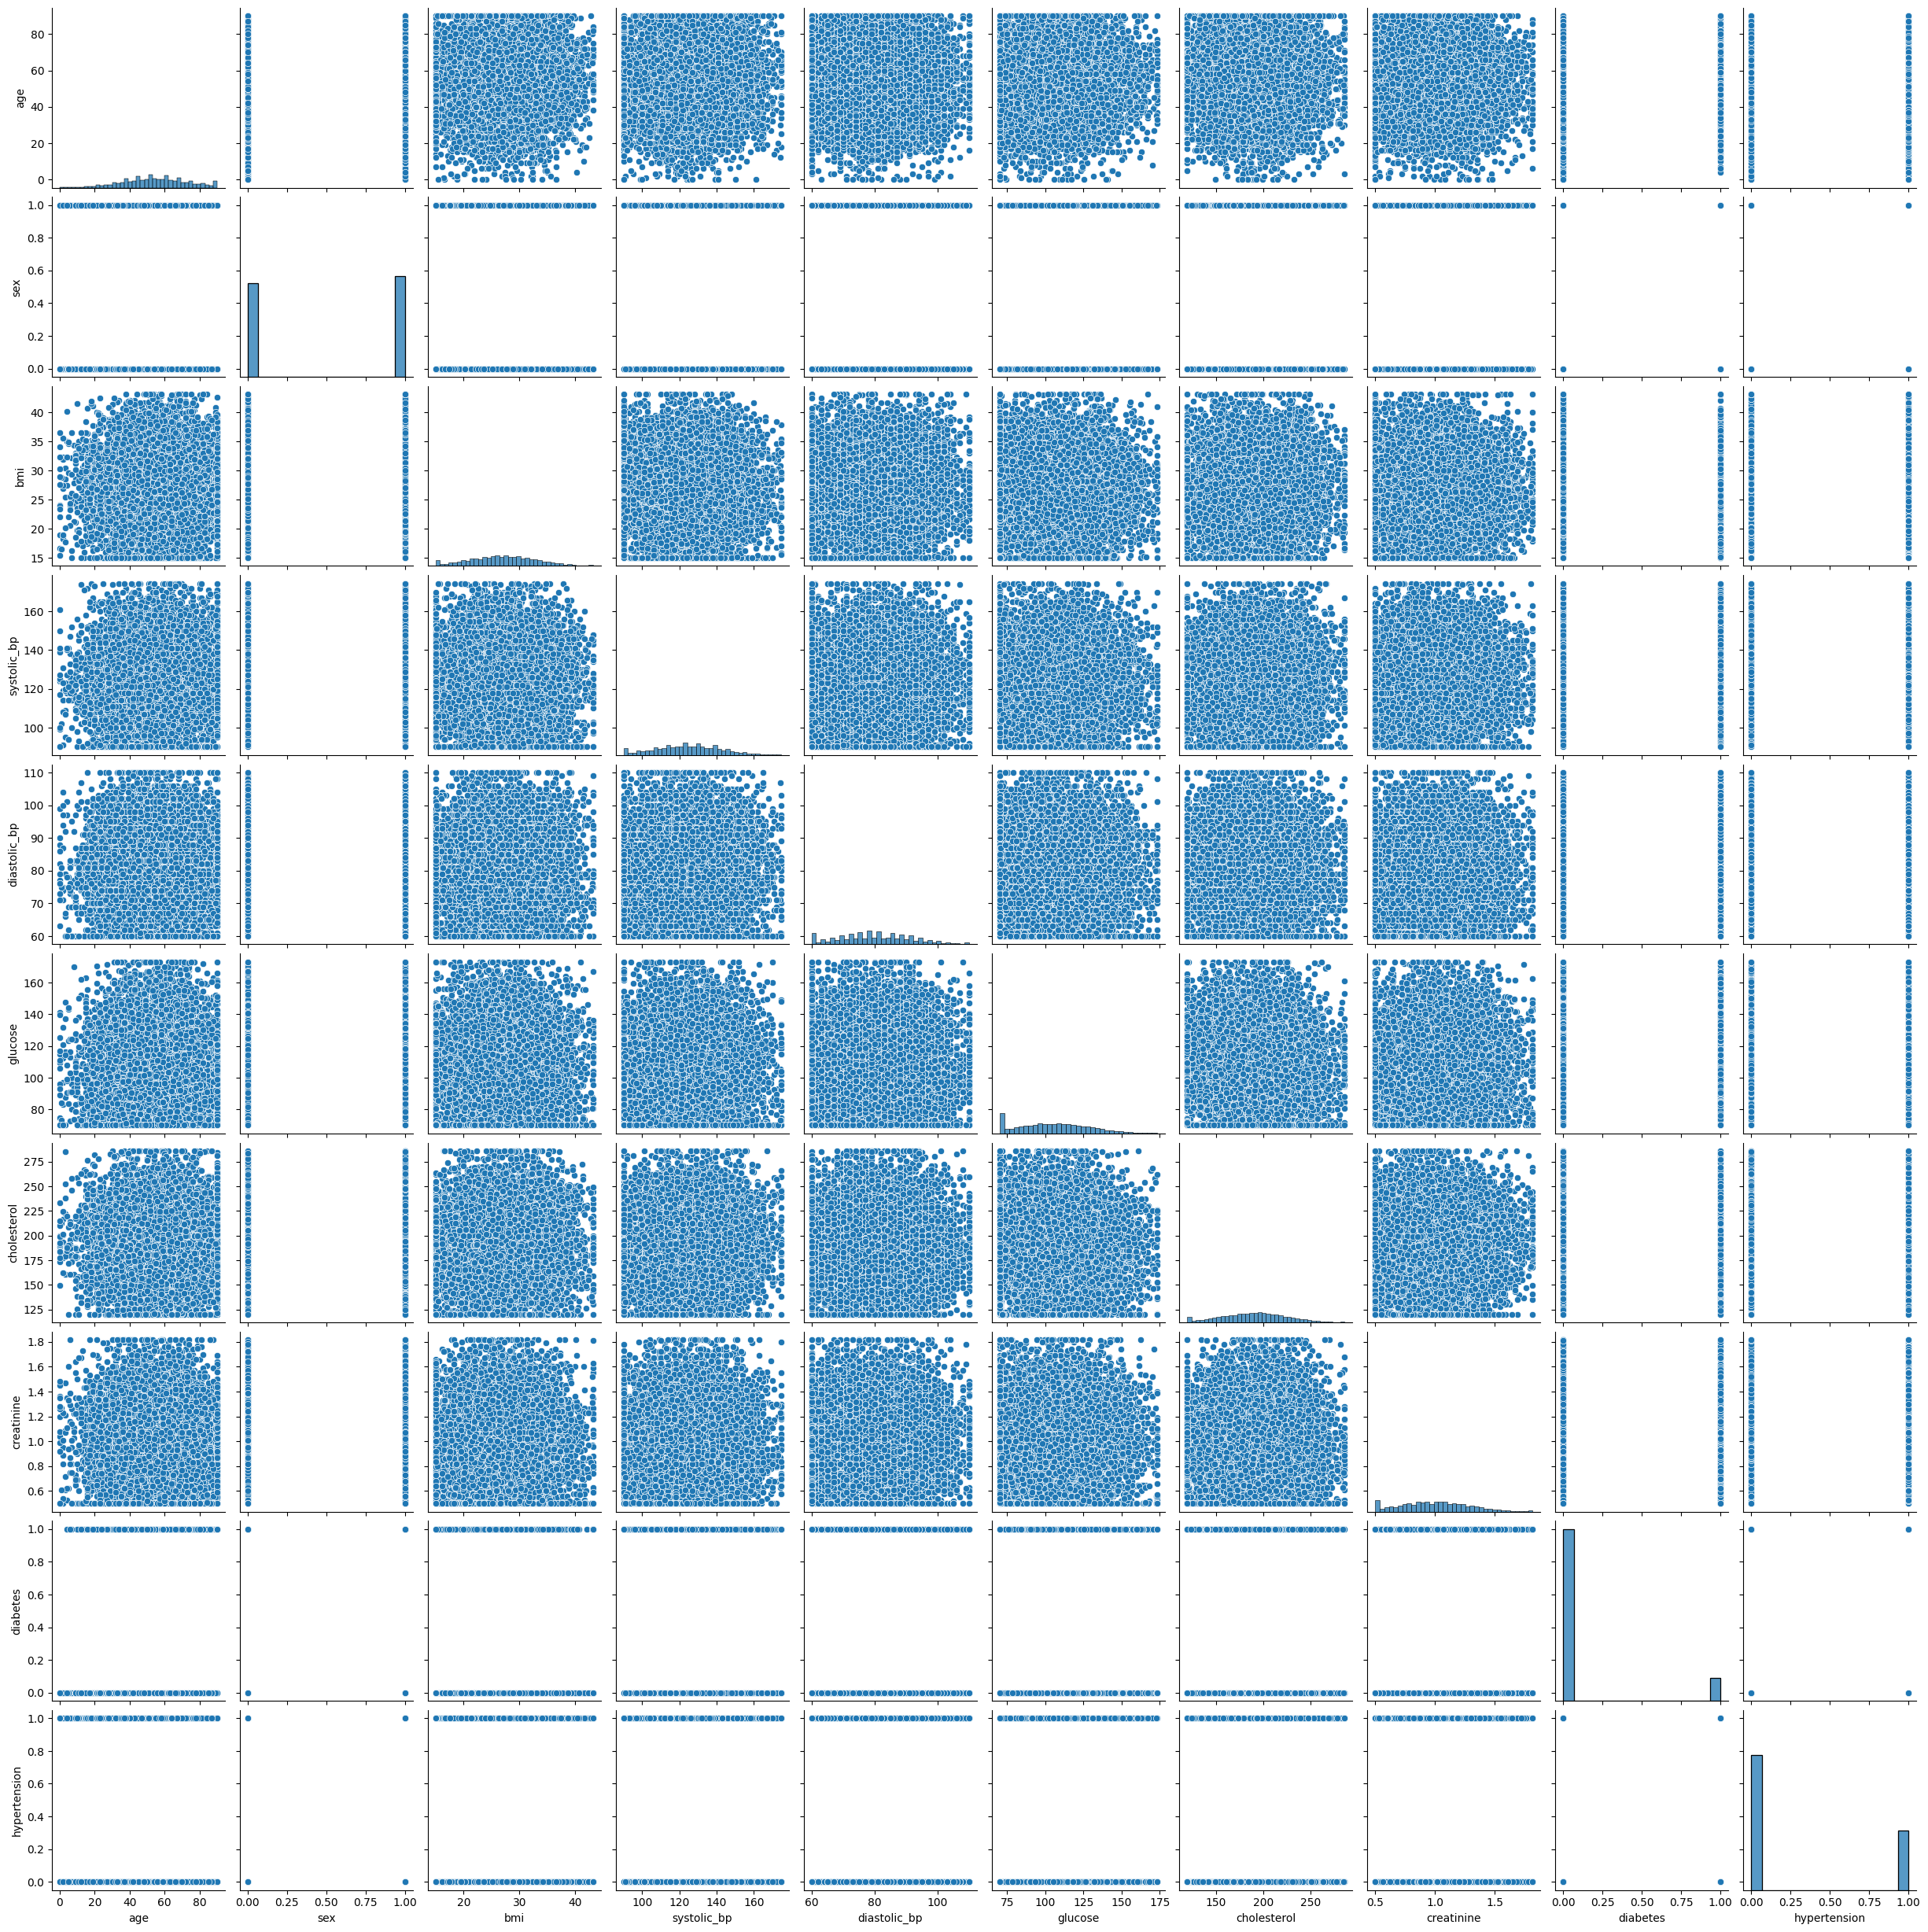

In [23]:
sns.pairplot(df_ml)
plt.show()

# K-means

In [21]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [19]:
cols_to_cluster = ['age','sex','bmi','systolic_bp','diastolic_bp','glucose','cholesterol','creatinine','diabetes','hypertension']

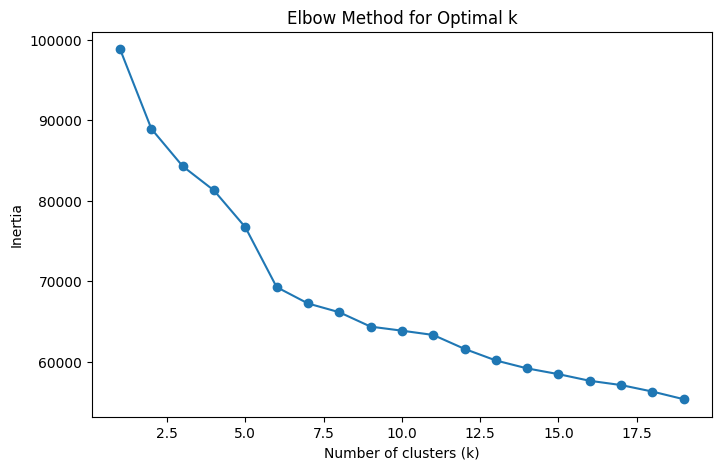

In [22]:
inertia = []
K_range = range(1, 20)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled[cols_to_cluster])
    inertia.append(kmeans.inertia_)

# lEbow method
plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

In [24]:
for k in range(2, 20):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(df_scaled)
    score = silhouette_score(df_scaled, labels)
    print(f"K={k}, Silhouette Score={score:.4f}")

K=2, Silhouette Score=0.1219
K=3, Silhouette Score=0.0816
K=4, Silhouette Score=0.0880
K=5, Silhouette Score=0.1007
K=6, Silhouette Score=0.1114
K=7, Silhouette Score=0.1042
K=8, Silhouette Score=0.1018
K=9, Silhouette Score=0.1019
K=10, Silhouette Score=0.0976
K=11, Silhouette Score=0.0913
K=12, Silhouette Score=0.0912
K=13, Silhouette Score=0.0914
K=14, Silhouette Score=0.0899
K=15, Silhouette Score=0.0894
K=16, Silhouette Score=0.0919
K=17, Silhouette Score=0.0904
K=18, Silhouette Score=0.0893
K=19, Silhouette Score=0.0893


- Applied K-Means clustering, but the Silhouette Scores are very low (<0.2) for all tested K values.
- This indicates that the data does not have well-defined clusters, likely due to high variability and overlap.
- K-Means may not be the best choice for this dataset; consider using density-based clustering (DBSCAN) or dimensionality reduction (PCA) first.

# DBSCAN

In [50]:
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA

In [40]:
dbscan = DBSCAN(eps=2.16, min_samples=5)

In [42]:
# Fit DBSCAN and get cluster labels
db_labels = dbscan.fit_predict(df_scaled)

# Add cluster labels to the dataframe
df_scaled['dbscan_cluster'] = db_labels

# Check number of clusters (-1 is noise)
num_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
num_noise = list(db_labels).count(-1)

print(f"Number of clusters found: {num_clusters}")
print(f"Number of noise points: {num_noise}")

Number of clusters found: 4
Number of noise points: 85


- The number of noise points is very small compared to the dataset,
- so they are not significant and can be ignored in the clustering analysis.

In [45]:
df_scaled['cluster'] = dbscan.labels_

In [47]:
cluster_summary = df_scaled.groupby('cluster').mean()
print(cluster_summary)

              age       sex       bmi  systolic_bp  diastolic_bp   glucose  \
cluster                                                                      
-1      -0.202178 -0.022445  0.199801     0.247700      0.114929  0.396129   
 0       0.000229  0.013336 -0.007894     0.002991     -0.007368  0.009408   
 1      -0.007998  0.003598  0.011590    -0.009223      0.021548 -0.035997   
 2       0.043965 -0.070352 -0.000112    -0.045364     -0.008561  0.018546   
 3       0.005337 -0.101780  0.000371     0.069815     -0.049566 -0.032572   

         cholesterol  creatinine  diabetes  hypertension  dbscan_cluster  
cluster                                                                   
-1         -0.114639    0.225306  1.920733      0.768973            -1.0  
 0          0.007795   -0.015196 -0.367666     -0.662201             0.0  
 1          0.001031    0.028837 -0.367666      1.510116             1.0  
 2          0.030158   -0.005459  2.719857     -0.662201             2.0  
 3 

- Cluster interpretation:
- Cluster 0 → Healthy individuals
- Cluster 1 → Hypertension patients
- Cluster 2 → Diabetes patients
- Cluster 3 → Patients with both diabetes and hypertension (high risk)
- Cluster -1 → Outliers / complex medical cases with multiple abnormal conditions

In [48]:
# Mapping clusters to medical labels
cluster_mapping = {
    0: 'Healthy',
    1: 'Hypertension',
    2: 'Diabetes',
    3: 'Diabetes + Hypertension',
    -1: 'High-risk / Outlier'
}

# Create new column with labels
df_scaled['condition'] = df_scaled['cluster'].map(cluster_mapping)

df_scaled[['cluster', 'condition']].head()

,cluster,condition
0,0,Healthy
1,1,Hypertension
2,0,Healthy
3,0,Healthy
4,0,Healthy


In [49]:
df_scaled

,age,sex,bmi,systolic_bp,diastolic_bp,glucose,cholesterol,creatinine,diabetes,hypertension,dbscan_cluster,cluster,condition
0,0.492122,-1.034802,-0.500261,0.351075,0.058076,1.293757,0.566612,0.127025,-0.367666,-0.662201,0,0,Healthy
1,-0.130882,-1.034802,-1.068372,-0.385890,0.936724,1.306622,0.496668,1.696640,-0.367666,1.510116,1,1,Hypertension
2,0.662032,-1.034802,0.515451,1.088041,-0.644843,-0.258627,-0.330996,0.510709,-0.367666,-0.662201,0,0,Healthy
3,1.568219,-1.034802,-1.756990,-0.726028,-0.381248,0.483258,1.091188,-1.442589,-0.367666,-0.662201,0,0,Healthy
4,-0.244156,0.966369,-0.276460,-1.292924,-1.347762,0.942112,-1.170318,1.312956,-0.367666,-0.662201,0,0,Healthy
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1.341672,0.966369,0.601529,-0.159131,1.727508,-0.537370,-0.430083,-0.954265,-0.367666,-0.662201,0,0,Healthy
9996,-1.999893,0.966369,1.238501,1.428179,-0.117654,0.358896,1.166960,0.057265,2.719857,-0.662201,2,2,Diabetes
9997,-0.697249,-1.034802,-0.586339,-0.555959,0.058076,-1.056261,1.743994,-1.756512,-0.367666,-0.662201,0,0,Healthy
9998,0.492122,0.966369,0.515451,1.314799,-0.644843,-1.176335,-0.182366,0.231666,-0.367666,-0.662201,0,0,Healthy


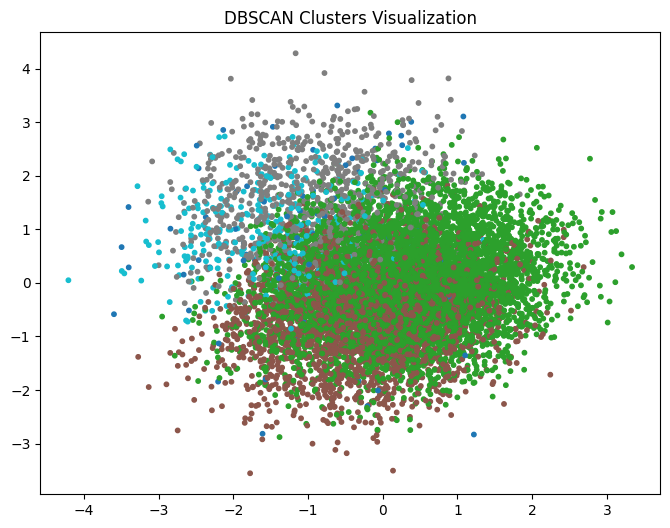

In [52]:
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled[cols_to_cluster])

plt.figure(figsize=(8,6))
plt.scatter(df_pca[:,0], df_pca[:,1], c=df_scaled['cluster'], cmap='tab10', s=10)
plt.title("DBSCAN Clusters Visualization")
plt.show()